# Punto 2: Dos heurísticas para A*

Mismo mapa de `12 × 12` que el punto 1. Comparamos A* con dos heurísticas admisibles en una cuadrícula de 4 vecinos y costo 1:

- Manhattan: $|x_n-x_g|+|y_n-y_g|$
- Euclidiana: $\sqrt{(x_n-x_g)^2+(y_n-y_g)^2}$

Manhattan nunca queda por debajo de Euclidiana en este dominio, así que aporta más información.

In [1]:
from heapq import heappush, heappop
from itertools import count
from pathlib import Path
from time import time
import math

from IPython.display import display
import matplotlib.pyplot as plt

In [2]:
# El mapa es el mismo del punto 1 para que la comparación de heurísticas
# use el mismo espacio de estados.
mapa = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
]

INICIO = (0, 0)
OBJETIVO = (11, 11)

MOVIMIENTOS = [
    (1, 0),
    (-1, 0),
    (0, 1),
    (0, -1),
]

CARPETA_IMAGENES = Path("../../results/informed-search/images")
CARPETA_IMAGENES.mkdir(parents=True, exist_ok=True)

In [3]:
def sucesores_mapa(mapa, posicion):
    filas = len(mapa)
    columnas = len(mapa[0])
    f, c = posicion
    sucesores = []

    for df, dc in MOVIMIENTOS:
        nf, nc = f + df, c + dc
        if (
            0 <= nf < filas
            and 0 <= nc < columnas
            and mapa[nf][nc] == 0
        ):
            sucesores.append((nf, nc))

    return sucesores


def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def euclidiana(a, b):
    # Distancia geométrica. En 4 vecinos queda por debajo de Manhattan.
    return math.hypot(a[0] - b[0], a[1] - b[1])

In [4]:
def a_estrella_mapa(mapa, inicio, objetivo, heuristica):
    """
    A* parametrizado. heuristica(nodo, objetivo) estima el costo restante.
    """
    desempate = count()
    frontera = []
    heappush(
        frontera,
        (heuristica(inicio, objetivo), 0, next(desempate), inicio, [inicio]),
    )

    mejor_g = {inicio: 0}
    expandidos = 0

    while frontera:
        f, g, _, nodo, camino = heappop(frontera)

        if g != mejor_g.get(nodo):
            continue

        expandidos += 1

        if nodo == objetivo:
            return {
                "camino": camino,
                "costo": g,
                "expandidos": expandidos,
            }

        for vecino in sucesores_mapa(mapa, nodo):
            nuevo_g = g + 1
            if nuevo_g < mejor_g.get(vecino, math.inf):
                mejor_g[vecino] = nuevo_g
                nuevo_f = nuevo_g + heuristica(vecino, objetivo)
                heappush(
                    frontera,
                    (nuevo_f, nuevo_g, next(desempate), vecino, camino + [vecino]),
                )

    return None

In [5]:
def medir(heuristica):
    t0 = time()
    resultado = a_estrella_mapa(mapa, INICIO, OBJETIVO, heuristica)
    resultado["tiempo"] = time() - t0
    return resultado


resultado_manhattan = medir(manhattan)
resultado_euclidiana = medir(euclidiana)

resultado_manhattan, resultado_euclidiana

({'camino': [(0, 0),
   (0, 1),
   (0, 2),
   (0, 3),
   (0, 4),
   (0, 5),
   (0, 6),
   (0, 7),
   (0, 8),
   (0, 9),
   (0, 10),
   (0, 11),
   (1, 11),
   (2, 11),
   (3, 11),
   (4, 11),
   (5, 11),
   (6, 11),
   (7, 11),
   (8, 11),
   (9, 11),
   (10, 11),
   (11, 11)],
  'costo': 22,
  'expandidos': 36,
  'tiempo': 8.177757263183594e-05},
 {'camino': [(0, 0),
   (0, 1),
   (0, 2),
   (0, 3),
   (0, 4),
   (0, 5),
   (0, 6),
   (0, 7),
   (0, 8),
   (0, 9),
   (0, 10),
   (0, 11),
   (1, 11),
   (2, 11),
   (3, 11),
   (4, 11),
   (5, 11),
   (6, 11),
   (7, 11),
   (8, 11),
   (9, 11),
   (10, 11),
   (11, 11)],
  'costo': 22,
  'expandidos': 37,
  'tiempo': 6.914138793945312e-05})

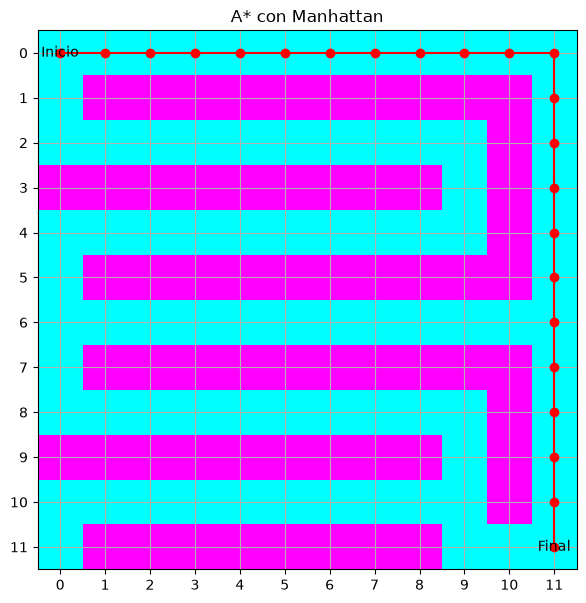

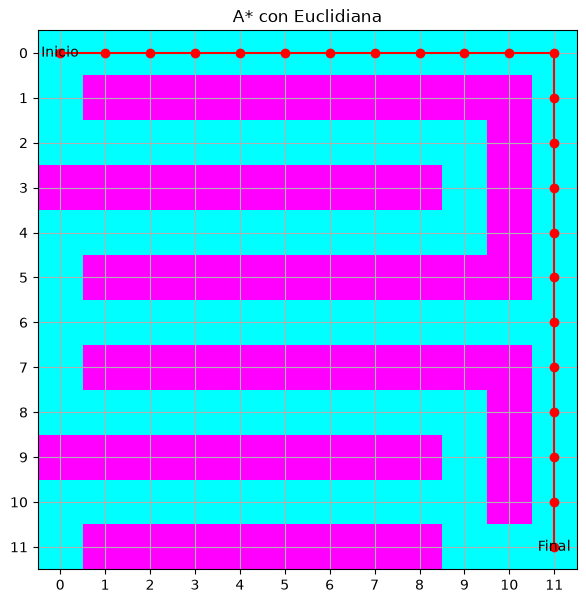

In [6]:
def mostrar_mapa(mapa, camino=None, inicio=None, objetivo=None, titulo="Mapa", archivo=None):
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(mapa, cmap="cool")

    if camino:
        xs = [c for f, c in camino]
        ys = [f for f, c in camino]
        ax.plot(xs, ys, c="red", marker="o")

    if inicio:
        ax.text(inicio[1], inicio[0], "Inicio", ha="center", va="center", fontsize=10)
    if objetivo:
        ax.text(objetivo[1], objetivo[0], "Final", ha="center", va="center", fontsize=10)

    ax.set_xticks(range(len(mapa[0])))
    ax.set_yticks(range(len(mapa)))
    ax.set_title(titulo)
    ax.grid(True)

    if archivo:
        fig.savefig(archivo, bbox_inches="tight")

    display(fig)
    plt.close(fig)


mostrar_mapa(
    mapa,
    resultado_manhattan["camino"],
    INICIO,
    OBJETIVO,
    "A* con Manhattan",
    CARPETA_IMAGENES / "2-manhattan.png",
)

mostrar_mapa(
    mapa,
    resultado_euclidiana["camino"],
    INICIO,
    OBJETIVO,
    "A* con Euclidiana",
    CARPETA_IMAGENES / "2-euclidiana.png",
)

In [7]:
comparacion = {
    "Manhattan": {
        "costo": resultado_manhattan["costo"],
        "expandidos": resultado_manhattan["expandidos"],
        "tiempo": resultado_manhattan["tiempo"],
    },
    "Euclidiana": {
        "costo": resultado_euclidiana["costo"],
        "expandidos": resultado_euclidiana["expandidos"],
        "tiempo": resultado_euclidiana["tiempo"],
    },
}

comparacion

{'Manhattan': {'costo': 22, 'expandidos': 36, 'tiempo': 8.177757263183594e-05},
 'Euclidiana': {'costo': 22,
  'expandidos': 37,
  'tiempo': 6.914138793945312e-05}}